# Comparing Marani-Inspired and Bernstein: Sensitivity to 1918 Flu Pandemic Outlier

- **Summary**: This document compares the our method inspired by [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) and the method from [Bernstein et al. (2022)](https://doi.org/10.1126/sciadv.abl4183) using Marani's data. We test the effect of using the severity of the 1918 pandemic from Bernstein (273.224 SMUs) instead of that from Marani (170.822 SMUs).

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral epidemic data

In [21]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [22]:
## Update the severity of the 1918 pandemic with Bernstein data
df_resp_viral.loc[df_resp_viral['year_start'] == 1918, 'severity_smu'] = 273.2240437


## 1. Set up exceedance probabilities from Madhav

In [23]:
## Read Madhav exceedance results from '03_resp_viral_comp'
df_madhav = pd.read_excel(cleandata_dir / "exceedance_results" / "madhav_original.xlsx")


In [24]:
## Set severeity points automatically 
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
                15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
                200, 220, 230, 240, 250, 260, 270, 280]

## Set up severity points manually
# severity = df_madhav['severity']
# severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]

## 2. Calibrate our own Marani-inspired method with more severe 1918 outlier

In [25]:
## Subset epidemic data to 1600-present
df_resp_viral_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_resp_viral_marani_inspired[df_resp_viral_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [26]:
## Display Marani-inspired data for GPD
df_marani_inspired_exceed 

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,west washington influenza,1836,1837,2,8.0,1147067.0,0.006974,0.069743,influenza,viral,droplet,1,0,1,0
2,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
3,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,273.224044,influenza,viral,droplet,1,0,1,1
4,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
5,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [27]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_inspired = genpareto.fit(df_marani_inspired_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_inspired)

(1.6734389582053533, 0.01, 2.191843379191201)


In [28]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_severe_marani_inspired = df_marani_inspired_exceed[(df_marani_inspired_exceed['year_start'] >= 2000) & 
                                                           (df_marani_inspired_exceed['year_start'] <= 2019)
                                                          ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme epidemic arrival rate: {round(arrival_severe_marani_inspired, 3)}/year')


Extreme epidemic arrival rate: 0.1/year


In [29]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_inspired * (1 - genpareto.cdf(severity, 
                                                                 *params_marani_inspired))

df_marani_inspired_outlier = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_inspired_outlier = df_marani_inspired_outlier.sort_values(by='severity', ascending=True)
df_marani_inspired_outlier = df_marani_inspired_outlier.reset_index(drop=True)


In [30]:
## Display exceedance results
df_marani_inspired_outlier

## Save to exceedance results folder
df_marani_inspired_outlier.to_excel(cleandata_dir / "exceedance_results" / "marani_inspired_outlier.xlsx", index=False)


,severity,exceedance
0,0.01,0.100000
1,0.04,0.098656
2,0.07,0.097359
3,0.08,0.096937
4,0.10,0.096107
5,0.40,0.085577
6,0.70,0.077656
7,1.00,0.071433
8,4.00,0.043375
9,7.00,0.033176


## 3. Calibrate Bernstein method with more severe 1918 outlier

In [31]:
## Subset epidemics to those with observable severities
df_resp_viral_known = df_resp_viral[df_resp_viral['death_thousand'] > 0
                                   ].reset_index(drop=True)

## Subset epidemics to those in the last century
df_resp_viral_known = df_resp_viral_known[
                        df_resp_viral_known['year_start'] >= 1900
                                        ].reset_index(drop=True)

## Display subsetted data
df_resp_viral_known


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"usa, yukon",1900,1900,1,0.100,1.633000e+06,0.000061,0.000612,influenza,viral,droplet,1,0,1,0
1,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,273.224044,influenza,viral,droplet,1,0,1,1
2,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0
3,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
4,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
5,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0
6,global sars,2003,2003,1,0.744,6.381185e+06,0.000117,0.001166,sars,viral,droplet,1,0,1,1
7,swine flu,2009,2009,1,284.500,6.872767e+06,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
8,global mers,2012,2017,6,0.659,7.125828e+06,0.000092,0.000925,mers,viral,droplet,1,0,1,1
9,indian swine flu outbreak,2015,2015,1,2.000,7.379797e+06,0.000271,0.002710,influenza,viral,droplet,1,0,1,0


In [32]:
## Define extreme severity threshold 
thresh = 10  ## Set to 10 SMU in accordance with Bernstein and Fan

## Define arrival and mean severity of all epidemics
p_a = 8 / 70  ## 8 epidemics in the past 70 years
mu_a = np.mean(df_resp_viral_known['severity_smu']) ## mean severity of all epidemics

## Define arrival and mean severity of extreme epidemics
p_x = 1 / 100  ## 1 extreme epidemic (1918 flu) in 100 years
mu_x = np.mean(df_resp_viral_known['severity_smu'][
    df_resp_viral_known['severity_smu'] >= thresh])  ## mean severity of extreme epidemics


In [33]:
## Find expected annual SMUs of all and extreme outbreaks
s_a = round(p_a * mu_a, 2)  ## expected annual severity of all outbreaks
s_x = round(p_x * mu_x, 2)  ## expected annual severity of extreme outbreaks

## Calibrate 'm'
m = round(1/(s_a), 2)  ## round 'm' to 2 decimals

## Display expected severities
print(f'Expected annual severity of all epidemics: {s_a} SMU')
print(f'Expected annual severity of extreme epidemics: {s_x} SMU')


Expected annual severity of all epidemics: 3.04 SMU
Expected annual severity of extreme epidemics: 2.73 SMU


In [34]:
## Define function to calibrate 'f' with conditional first moment
def calibrate_hyperbolic_f(m, thresh, s_x):
    """
    Calibrate the parameter 'f' for a hyperbolic function from Fan et al. 
    (2018) based on the first moment conditional on exceedance.

    Parameters:
    - m: float, parameter of the hyperbolic model.
    - thresh: float, threshold value for extreme severities.
    - s_x: float, annual expected extreme severity.

    Returns:
    - f_opt: float, the optimal value of 'f' that minimizes the difference 
      between the integral and the conditional first moment.
    """
    
    ## Define integrand for hyperbolic exceedance
    def integrand(s, m, f):
        return (1 + m * (1 - f) * s) ** (-1 - 1 / (1 - f))
    
    ## Define the objective function to minimize
    def objective(f, m, s_x):
        integral, _ = quad(integrand, thresh, np.inf, args=(m, f))
        return (s_x - integral) ** 2
    
    ## Set bounds for 'f'
    bounds = [(-200, -1)]
    
    ## Minimize difference between integral and conditional moment
    ## x0 is the initial guess for 'f'
    result = minimize(objective, x0=-2, args=(m, s_x), bounds=bounds)
    
    ## Print result
    if result.success:
        if result.fun < 1e-08:
            print("Convergence succeeded! :)")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
        else:
            print("Convergence failed. :(")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
    else:
        print("Optimization failed. :(")
        print("Objective function value: NA")
    
    ## Return optimal value of 'f'
    f_opt = result.x[0] if result.success else None
    return f_opt

## Example usage:
## m = 0.23
## thresh = 10
## s_x = 2.97
## f = calibrate_hyperbolic_f(m, thresh, s_x)    


In [35]:
## Calibrate 'f'
f = calibrate_hyperbolic_f(m, thresh, s_x) 
f = round(f, 2)  ## round 'f' to 2 decimals


Convergence failed. :(
Minimized cost value: 7.097717590911079e-07
Optimal value of f: -47.56


In [36]:
print(f'Result: m = {m}, f = {f}')

Result: m = 0.33, f = -47.56


In [37]:
## Calculate Bernstein exceedance probabilities
exceedance = [(1 + m * (1 - f) * s)**(-1 - 1/(1 - f)) for s in severity]

## Create dataframe on exceedance probabilities
df_bernstein_outlier = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index
df_bernstein_outlier = df_bernstein_outlier.sort_values(by='severity', ascending=True)
df_bernstein_outlier = df_bernstein_outlier.reset_index(drop=True)

## Display severities and exceedance probabilities
df_bernstein_outlier

## Save to exceedance results folder
df_bernstein_outlier.to_excel(cleandata_dir / "exceedance_results" / "bernstein_outlier.xlsx", index=False)


,severity,exceedance
0,0.01,0.859251
1,0.04,0.603203
2,0.07,0.464067
3,0.08,0.430833
4,0.10,0.376755
5,0.40,0.129501
6,0.70,0.077739
7,1.00,0.055407
8,4.00,0.014095
9,7.00,0.008016


## 4. Visualize sensitivity to outlier

In [38]:
## Read exceedance results from benchmark models
df_marani_inspired = pd.read_excel(cleandata_dir / "exceedance_results" / "marani_inspired.xlsx")
df_bernstein = pd.read_excel(cleandata_dir / "exceedance_results" / "bernstein_original.xlsx")

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.01, 1000.0)

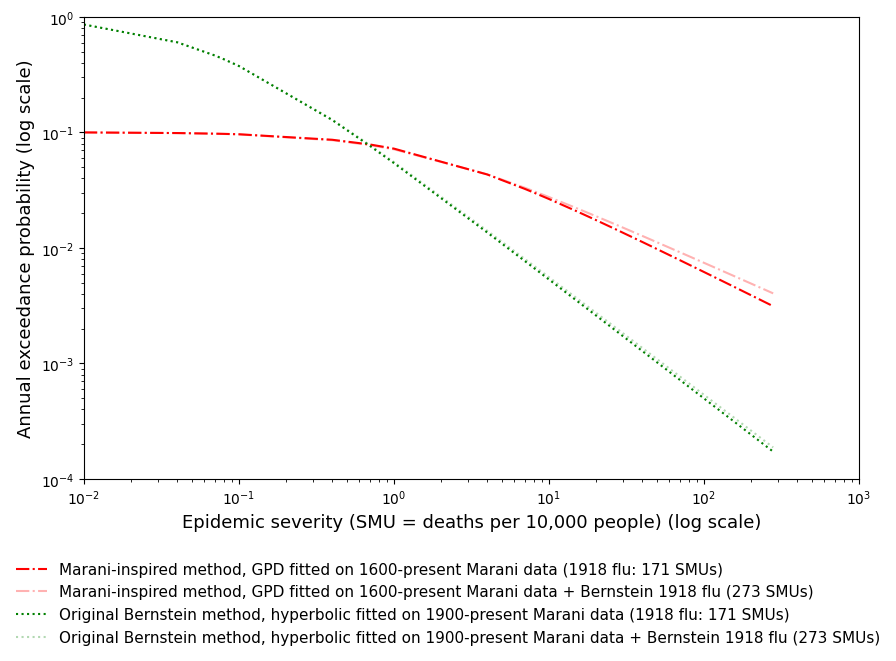

In [39]:
## Plot comparison across Marani and Bernstein 
plt.figure(figsize=(10, 6))


## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present Marani data (1918 flu: 171 SMUs)')

## Plot for Marani-inspired with severe outlier
plt.plot(df_marani_inspired_outlier['severity'], df_marani_inspired_outlier['exceedance'], 
         color='red', linestyle='-.', alpha=0.3,
         label='Marani-inspired method, GPD fitted on 1600-present Marani data + Bernstein 1918 flu (273 SMUs)')


## Plot for Bernstein original
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
         color='green', linestyle=':', alpha=1,
         label='Original Bernstein method, hyperbolic fitted on 1900-present Marani data (1918 flu: 171 SMUs)')

## Plot for Bernstein with severe outlier
plt.plot(df_bernstein_outlier['severity'], df_bernstein_outlier['exceedance'], 
         color='green', linestyle=':', alpha=0.3,
         label='Original Bernstein method, hyperbolic fitted on 1900-present Marani data + Bernstein 1918 flu (273 SMUs)')


# ## Plot for Madhav
# plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
#          color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Bernstein and Marani-Inspired Methods: Sensitivity to 1918 Flu Outlier', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '06c_sensitivity_data_outlier.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()

